**Author:** Salvador Navas  
**Date:** 2025-06-27

# Bias Correction of Climate Model Output

Bias correction (or statistical downscaling) adjusts systematic errors in Global Climate Model (GCM) 
output so that the corrected series matches the statistical properties of observed data.
It is a mandatory pre-processing step before using GCM projections in hydrological impact studies.

---

## When to apply bias correction?

| Situation | Recommended? |
|-----------|-------------|
| GCM used directly as catchment rainfall | ✅ Always |
| Regional Climate Model (RCM) with fine resolution | ✅ Yes, but bias is usually smaller |
| Temperature for PET calculation | ✅ Yes |
| Relative changes only (delta factors for scenarios) | ⚠️ Delta method is sufficient |
| Validation of a hydrological model against observations | ❌ Use observations directly |

---

## Four methods implemented in pyhydra

| Method | Key idea | Result |
|--------|----------|--------|
| **Delta** | Apply monthly change factors to observed series | 1 series per climate variable |
| **QM** (Quantile Mapping) | Match GCM quantiles to observed quantiles | 1 series per GCM model |
| **QDM** (Quantile Delta Mapping) | Preserve the modelled climate-change signal in the quantiles | 1 series per GCM model |
| **SDM** (Scaled Distribution Mapping) | Parametric distribution fit; handles wet-day frequency | 1 series per GCM model |

> **Recommended workflow:** apply bias correction to the **historical** simulation period first,
> compare with observations to validate, then apply the calibrated correction to the **future** period.

---

## Calibration vs projection period

- **Calibration (reference) period**: typically 1950–2005 or 1980–2010 (WMO 30-year normals).
  Observations and GCM historical run must overlap.
- **Projection period**: 2021–2040 (near future), 2041–2070 (mid-century), 2071–2100 (end of century).
  Only the calibrated transfer function is applied — no observations needed.

> ⚠️ **Stationarity caveat:** QM and Delta assume that the bias pattern calibrated in the historical
> period remains valid in the future. QDM and SDM explicitly account for non-stationarity by preserving
> the modelled relative change signal.


The resolution of GCM models has spatial scales on the order of hundreds of kilometers. Therefore, it is necessary to downscale to a smaller scale to obtain climate change forecast results that are more consistent with observed reality. This process is known as **downscaling**. Downscaling, essential in climate research, is mainly divided into two approaches: statistical and dynamical, each with distinctive characteristics and specific applications.

Over the years, numerous bias correction methods have been developed, using univariate and multivariate approaches. These methods are divided into two main groups:

- Application of anomalies to instrumental series, or delta method.
- Transformations through distribution functions, or mapping methods.

### Description of Statistical Downscaling Techniques

#### Mapping Methods

Mapping methods, in simplified terms, consist of calibrating the cumulative distribution function (CDF) of the simulated series from climate change models using the CDF of observed series, according to the following formulation:

$$
q_m^* = F_o^{-1} (F_m (q_m )),
$$

where $q_m$ and $q_m^*$ are the simulated and bias-corrected quantiles of the global climate model, and $F_m$ and $F_o$ are the empirical CDFs of the simulated and observed data, respectively. Depending on the type of mapping, the calibration of the CDF is carried out differently.

Any mapping technique can easily be applied to account for changes in the distribution of the variable of interest between different time periods. In this case, the formula takes the following form:

$$
q_{\text{raw}}^*=F_{\text{obs}}^{-1} (F_{\text{mod}} (q_{\text{raw}} )),
$$

where $q_{\text{raw}}$ and $q_{\text{raw}}^*$ are the quantiles of the original and corrected GCM series for the future period, and $F_{\text{mod}}$ and $F_{\text{obs}}$ are the empirical CDFs of the GCM and observed series for the reference period 1950-2005, respectively. The observed series used as reference stations are those extracted from points distributed within the study basin.

In the case of using the **Scaled Distribution Mapping (SDM)** method, it is necessary to define the type of climate variable being studied since the way of calibrating the distribution function differs; for example, in precipitation there are days with no rainfall.

Below is a schematic representation of the process followed when applying mapping methods to update climate series for future projections.

**Figure 8: Downscaling process through mapping methods.**

![Figure1](../data/FIGURAS/Metodos_QQ.png)
*Downscaling process through mapping methods. Source: Navas, S., del Jesus, M., & Gómez, D. V. (2022). Methodological guide for estimating minimum reservoir inflows in the context of climate change. Fundación Canal. https://www.fundacioncanal.com/docs/guia_embalses_cbio_climatico_FundCanal_2022.pdf*

The methods are described below.

- **Quantile Mapping (QM)**

The scientific community has made great efforts to review and compare many popular existing bias correction methods and has found that quantile mapping (QM) outperforms other methods. At the same time, studies have pointed out serious problems when using QM for bias correction (Switanek et al., 2017). In particular, the method can alter the projected changes of the raw model (Themeßl et al., 2012). This inflation or deflation of the simulated climate change signal exists as an artifact of the stationarity assumption. QM assumes that bias correction values established in a calibration period can be applied to any time period within or outside the calibration period.

QM corrects biases in the distribution of a simulated variable by comparing the model’s raw output with an observational distribution of the same variable. Simulated and observed distributions are approximately matched by establishing a quantile-dependent correction function that maps simulated quantiles to their observed counterparts based on the difference of quantiles. This function is then used to translate a transient simulated time series into a corrected series. The implicit assumption of QM is that a climate model can accurately project the ranked categories (quantiles) of the variable of interest but not their actual values. Simulated and observed quantiles can be based on the complete empirical distribution (non-parametric implementation) or a fitted theoretical distribution (parametric implementation).

- **Quantile Delta Mapping (QDM)**

QDM differs from traditional QM methods in that it is not limited by the assumption of stationarity. In traditional QM, a modeled raw value is always corrected by the same bias determined by its respective quantile in the calibration period. In contrast, QDM multiplies observed values by the ratio of modeled values (for the period of interest determined by the calibration period) in the same quantiles (Cannon et al., 2015). The procedure is similar to QM but here simulated and observed distributions are adjusted using a quantile-dependent correction function based on the relative change of quantiles.

- **Scaled Distribution Mapping (SDM)**

SDM shares some similarities with QDM; however, there are three important differences:

- SDM uses a parametric model rather than a non-parametric one.
- SDM and QDM handle zero precipitation days very differently.
- SDM more accurately accounts for differences in modeled variances (for temperature) between the period of interest and the calibration period (Switanek et al., 2017).

The correction procedure is based on comparing simulated and observed quantiles through a parametric distribution function, such as gamma or normal, depending on the type of variable. For precipitation, the gamma function is used to handle rain and no-rain days, while for temperature, the normal function is used to better account for modeled variances.

#### Application of Anomalies to Instrumental Series or Delta Method

The delta change approach is an alternative to the direct use of RCM simulations. It is based on the spatial interpolation of monthly anomalies (deltas) from the original RCM or GCM outputs. The anomalies are interpolated between the centroids of GCM or RCM grid cells and then applied to a given reference climate. Its main disadvantage is that temporal patterns of climate variables will not change in future scenario simulations. For example, the number of rainy days will not change with the delta approach.

This method allows determining, from climate model predictions, what correction should be added to observations to convert them into equivalent future-period observations:

$$
y^f = y^p + (\bar{x}^f - \bar{x}^p )
$$

![Figure1](../data/FIGURAS/Delta_1.png)
*Graphical representation of the delta method application for bias correction of a temperature climate series. Source: Navas, S., del Jesus, M., & Gómez, D. V. (2022). Methodological guide for estimating minimum reservoir inflows in the context of climate change. Fundación Canal. https://www.fundacioncanal.com/docs/guia_embalses_cbio_climatico_FundCanal_2022.pdf*

For positive-value variables, such as precipitation, a modification based on relative change can also be carried out:

$$
y^f = y^p \times (\bar{x}^f/\bar{x}^p)
$$

![Figure1](../data/FIGURAS/Delta_2.png)
*Graphical representation of the delta method application for bias correction of a precipitation climate series. Source: Navas, S., del Jesus, M., & Gómez, D. V. (2022). Methodological guide for estimating minimum reservoir inflows in the context of climate change. Fundación Canal. https://www.fundacioncanal.com/docs/guia_embalses_cbio_climatico_FundCanal_2022.pdf*

It is important to note that when applying the delta method through equation (1), the variability of the series remains unaltered, meaning it produces the same variance as the original. However, when applied through equation (2), the variability is reduced by the same proportion as the mean, thus producing the same coefficient of variation as the original.

Generally, applying the change through differences (equation 1) is used for temperatures, as absolute increases or decreases are used. For hydrological variables or precipitation, relative change (equation 2) is applied, which implies that reducing the mean also reduces its variance.

This method can also be performed monthly, meaning $y^p$ are the observed values for the reference period in a given month, while $y^f$ are the updated series values for that month. $\bar{x}^f$ and $\bar{x}^p$ are the monthly means from the climate model historical and scenario series.

For example, to update a series to the future, first iterate over each month of the year, calculating the mean of the variable for both the historical and scenario climate model series, obtaining 12 change factors, one per month.

The objective of applying this method is to reduce the number of resulting future series; thus, an ensemble of the different change results from each model is required.

Two ensemble methods can be used: mean or median of change factors. The table below shows their pros and cons.

**Pros and cons of statistical ensemble methods for delta factors**

| Delta ensemble method | Pros | Cons |
|------------------------|------|------|
| Mean (𝝁) | 1. Considers all values | 1. Outlier values can significantly increase or decrease the result |
| Median (M_e) | 1. Avoids outliers affecting the final result | 1. May underestimate the final result |

The final ensemble result is a set of 12 values, one for each month. These change factors are applied iteratively to the historical series $y^p$ to obtain the future series for the climate change scenario $y^f$.

Below is a schematic representation of the delta method application.

![Figure1](../data/FIGURAS/Metodo_Delta.png)
*Downscaling process through the delta method. Source: Navas, S., del Jesus, M., & Gómez, D. V. (2022). Methodological guide for estimating minimum reservoir inflows in the context of climate change. Fundación Canal. https://www.fundacioncanal.com/docs/guia_embalses_cbio_climatico_FundCanal_2022.pdf*

Finally, the pros and cons of different downscaling methods are shown below:

| Downscaling Methods | Pros | Cons |
|---------------------|------|------|
| QQM | 1. Widely used by the scientific community. <br> 2. Does not account for type of climate variable. <br> 3. Does not account for number of rainy days. <br> 4. Assumes stationarity | Number of series equals number of climate models per scenario |
| QDM | 1. Widely used by the scientific community. <br> 2. Not limited by stationarity assumption | 1. Does not account for type of climate variable. <br> 2. Does not account for number of rainy days. <br> 3. Number of series equals number of climate models per scenario |
| SDM | 1. Accounts for frequency of rainy days (for precipitation) and event probability. <br> 2. Does not depend on invalid stationarity assumption | 1. Longer execution time <br> 2. Number of series equals number of climate models per scenario |
| Delta method | 1. Single series per climate variable. <br> 2. Short execution time to update climate series | 1. Greater uncertainty due to resulting in a single flow series. <br> 2. Annual seasonality repeats every year in the future series. <br> 3. Does not account for number of rainy days. |


### Application of Statistical Downscaling Techniques

As previously mentioned, statistical downscaling using the quantile mapping method involves adjusting the probability distributions of climate model outputs to local observations through quantile transformation. The general procedure is as follows:

1. **Data Selection:** Collect local observational data for the climate variable of interest and outputs from the global or regional climate model. It is necessary to ensure that the time series are comparable and have the same temporal frequency.

2. **Data Preprocessing:** Perform any necessary adjustments to the data, such as temporal or spatial interpolation to match the temporal and spatial scales.

3. **Establishment of Reference Periods:** Define reference periods for observations and model outputs. These periods will be used to adjust the quantile distributions. A popular climatological reference period is a "normal" period of around 20–30 years, as defined by the World Meteorological Organization (WMO).

   - **Sufficient Temporal Length:** A period of 20 or 30 years provides adequate temporal length to capture short- and long-term climate variability. It allows observation of seasonal and annual climate patterns, as well as longer-term trends.
   - **Reduction of Interannual Variability:** Considering a period of several decades reduces the influence of interannual climate variability. This helps separate natural climate variations from longer-term trends, facilitating clearer assessment of climate change.
   - **Statistical Representativeness:** The choice of 20–30 year periods aligns with the concept of “climatology,” referring to typical climate conditions of a region over a long period.
   - **Consistency with International Standards:** The WMO and other international bodies have adopted 20–30 year reference periods to define “climate normals.”
   - **Evaluation of Long-Term Trends:** Longer periods are essential for evaluating long-term climate trends, such as those related to climate change.
   - **Stability in the Definition of Climate Normals:** Using 20 or 30-year periods maintains stability in defining climate normals, facilitating comparison of climate data worldwide and over time.

4. **Calculation of Empirical Quantiles:** Calculate empirical quantiles for both observations and model outputs for the reference periods. These quantiles represent specific values in the cumulative probability distribution.

5. **Quantile Adjustment:** Adjust the model output quantiles to match the observational quantiles. This involves applying an adjustment function that relates the quantiles of the two datasets.

6. **Quantile Mapping:** For each point in the model dataset, apply the adjustment function to map the model quantiles to observational quantiles. This will adjust the probability distributions and provide more detailed and locally consistent projections.

7. **Application to Future:** Use the adjusted mapping function to project future climate conditions from the model outputs for future periods.

In this study, we selected the historical period 1995–2014 and will evaluate changes in the future period 2021–2040.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyhydra.climate.bias_correction import delta_method as Delta
from pyhydra.climate.bias_correction import BiasCorrection as QM

In [2]:
# Synthetic precipitation data with realistic intermittency (dry/wet days)
rng = np.random.default_rng(42)
dates_hist = pd.date_range("1980-01-01", "2009-12-31", freq="D")
dates_fut  = pd.date_range("2070-01-01", "2099-12-31", freq="D")

from scipy.stats import gamma

def _precip(dates, p_wet, shape, scale, seed):
    n = len(dates)
    rng2 = np.random.default_rng(seed)
    wet = rng2.random(n) < p_wet
    intensity = gamma.rvs(shape, scale=scale, size=n, random_state=seed)
    return np.where(wet, intensity, 0.0)

# Observed: 35 % wet days, gamma(0.8, scale=8)
Series_Prec_st  = pd.Series(
    _precip(dates_hist, p_wet=0.35, shape=0.8, scale=8, seed=0),
    index=dates_hist, name="obs"
)
# Model historical: 38 % wet days (slight wet bias), scale=9
Series_Prec_mod = pd.Series(
    _precip(dates_hist, p_wet=0.38, shape=0.8, scale=9, seed=1),
    index=dates_hist, name="mod_hist"
).to_frame()
# Model future: 40 % wet days (climate change signal), scale=11
Series_Prec_Fut = pd.Series(
    _precip(dates_fut, p_wet=0.40, shape=0.85, scale=11, seed=2),
    index=dates_fut, name="mod_fut"
).to_frame()

obs_wet  = (Series_Prec_st  > 0).mean() * 100
mod_wet  = (Series_Prec_mod.iloc[:,0] > 0).mean() * 100
fut_wet  = (Series_Prec_Fut.iloc[:,0] > 0).mean() * 100
print(f"Obs historical : {len(Series_Prec_st)} days  mean={Series_Prec_st.mean():.2f} mm  wet={obs_wet:.0f}%")
print(f"Model historical: {len(Series_Prec_mod)} days  mean={Series_Prec_mod.iloc[:,0].mean():.2f} mm  wet={mod_wet:.0f}%")
print(f"Model future    : {len(Series_Prec_Fut)} days  mean={Series_Prec_Fut.iloc[:,0].mean():.2f} mm  wet={fut_wet:.0f}%")

Obs historical : 10958 days  mean=2.19 mm  wet=35%
Model historical: 10958 days  mean=2.72 mm  wet=38%
Model future    : 10957 days  mean=3.73 mm  wet=40%


#### Application of the Delta Method

The delta method is applied below to calculate the modified series of a climate variable (such as precipitation) for a future period.

The following code uses this function to calculate the modified future precipitation series (`Serie_Fut_delta`) from a historical observed series (`Serie_Prec_st`), a historical global model series (`Serie_Prec_mod`), and a future global model series (`Serie_Prec_Fut`). Then, the monthly means of these series are calculated and stored in `serie_hist_models_month_g` and `Serie_Fut_delta_month_g`, respectively.


In [4]:
Serie_Fut_delta = pd.DataFrame(Delta(Series_Prec_st, Series_Prec_mod, Series_Prec_Fut, 'pr', 'median')) # Aplicamos el método delta 
Serie_Fut_delta.columns = ['pr']

In [5]:
# Calculate monthly accumulated precipitation from the historical series Serie_Prec_st
serie_hist_month = Series_Prec_st.resample('ME').sum()

# Calculate the monthly mean of historical accumulated precipitation grouped by month
# The data is grouped by month, and the mean for each month is calculated
serie_hist_models_month_g = serie_hist_month.groupby(by=serie_hist_month.index.month).mean()

# Calculate monthly accumulated precipitation for the modified future precipitation series Serie_Fut_delta
Serie_Fut_delta_month = Serie_Fut_delta.resample('ME').sum()

# Calculate the monthly mean of the modified future accumulated precipitation grouped by month
# The data is grouped by month, and the mean for each month is calculated
Serie_Fut_delta_month_g = Serie_Fut_delta_month.groupby(by=Serie_Fut_delta_month.index.month).mean()


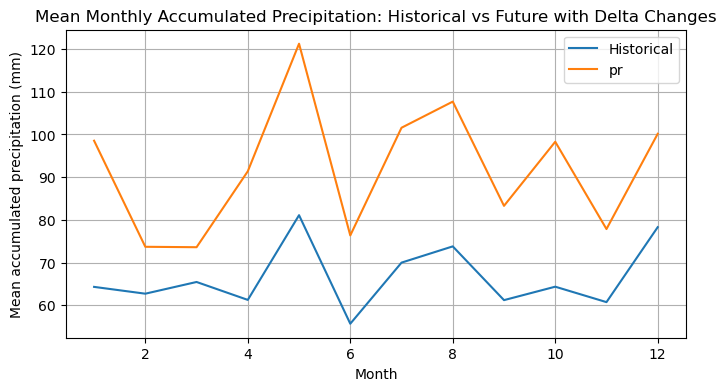

In [6]:
# Create the figure and axes
plt.figure(figsize=(8, 4))
ax = plt.gca()

# Mean monthly accumulated precipitation for the historical period
serie_hist_models_month_g.plot(label='Historical', ax=ax)

# Mean monthly accumulated precipitation for the future period with delta changes
Serie_Fut_delta_month_g.plot(label='Future with Delta Changes', ax=ax)

# Configure legend and title
plt.legend()
plt.title('Mean Monthly Accumulated Precipitation: Historical vs Future with Delta Changes')
plt.xlabel('Month')
plt.ylabel('Mean accumulated precipitation (mm)')

# Show the figure
plt.grid(True)
plt.show()


#### Application of Quantile Mapping Techniques

Downscaling is performed below using different quantile mapping methods.

1. **Concatenate historical observations and model simulations series**: The historical observations and model simulations series are concatenated using pandas' `concat()` method. Then, rows containing null values are removed with `dropna()`.

2. **Perform bias correction**: The `bias_correction()` function is used to perform bias correction between the historical observations and the model simulations.

3. **Create copies of the future precipitation series**: Copies of the future precipitation series are created for each bias correction method.

4. **Apply different bias correction methods**: The different bias correction methods are applied to the future precipitation series using the previously calculated bias correction results.

5. **Calculate statistics for each future precipitation series**: Statistics such as mean, variance, maximum, percentage of dry days, and percentage of wet days are calculated for each future precipitation series.

6. **Create DataFrames with the statistics**: DataFrames are created from the statistics dictionaries for each bias correction method.

7. **Concatenate the DataFrames to obtain a final DataFrame**: The statistics DataFrames for each bias correction method are concatenated to obtain a single final DataFrame (`resultados`) containing the statistics for each method.


In [7]:
# Concatenate the historical observation series and model simulation series
concat = pd.concat((Series_Prec_st, Series_Prec_mod), axis=1).dropna()

# Perform bias correction between the historical observations and the model simulations
b_correct = QM(concat.iloc[:, 0].values, concat.iloc[:, 1].values, Series_Prec_Fut.iloc[:, 0].values)


In [8]:
# Create copies of the future precipitation series for each bias correction method
Serie_Fut_QQM = Series_Prec_Fut.copy()
Serie_Fut_QDM = Series_Prec_Fut.copy()
Serie_Fut_SDM = Series_Prec_Fut.copy()

# Apply the different bias correction methods to the future precipitation series
Serie_Fut_QQM.iloc[:,0] = b_correct.quantile_mapping()
Serie_Fut_QDM.iloc[:,0] = b_correct.quantile_deltamapping()
Serie_Fut_SDM.iloc[:,0] = b_correct.scaled_distribution_mapping('precipitation')


### CDF and monthly means comparison

The empirical cumulative distribution function (ECDF) is the most direct way to assess how well each method corrects the distributional bias. A well-corrected series should have its ECDF as close as possible to the observed one.

- **Left panel**: ECDF of observed, raw future model, and each corrected series. The ideal correction collapses onto the observed curve.
- **Right panel**: monthly daily means showing seasonal bias before and after correction.

In [ ]:
def _ecdf(arr):
    """Sorted values and Hazen plotting positions."""
    s = np.sort(arr)
    p = np.arange(1, len(s) + 1) / (len(s) + 1)
    return s, p

def _monthly_means(arr):
    """Calendar-month daily means (assumes Jan-1 start, non-leap years)."""
    days_per_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    template = np.repeat(np.arange(1, 13), days_per_month)
    n = len(arr)
    months = np.tile(template, n // 365 + 1)[:n]
    return np.array([arr[months == m].mean() for m in range(1, 13)])

# Raw arrays
obs_arr = Series_Prec_st.values
raw_arr = Series_Prec_Fut.values.ravel()
qm_arr  = Serie_Fut_QQM.values.ravel()
qdm_arr = Serie_Fut_QDM.values.ravel()
sdm_arr = Serie_Fut_SDM.values.ravel()

COLORS = {
    'Observed':  '#1f77b4',
    'Raw model': '#9ca3af',
    'QM':        '#f59e0b',
    'QDM':       '#10b981',
    'SDM':       '#ef4444',
}
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: ECDF ──────────────────────────────────────────────────────────────
for label, arr, ls, lw in [
    ('Observed',  obs_arr, '-',  2.2),
    ('Raw model', raw_arr, '--', 1.5),
    ('QM',        qm_arr,  '-',  1.5),
    ('QDM',       qdm_arr, '-',  1.5),
    ('SDM',       sdm_arr, '-',  1.5),
]:
    x, p = _ecdf(arr)
    ax1.plot(x, p, color=COLORS[label], ls=ls, lw=lw, label=label)

ax1.set_xlabel('Precipitation (mm/day)', fontsize=11)
ax1.set_ylabel('Cumulative probability', fontsize=11)
ax1.set_title('Empirical CDF comparison', fontsize=12, fontweight='bold')
ax1.set_xlim(left=0)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Right: monthly means ─────────────────────────────────────────────────────
x = np.arange(12)
w = 0.14
series_list = [
    ('Observed',  obs_arr),
    ('Raw model', raw_arr),
    ('QM',        qm_arr),
    ('QDM',       qdm_arr),
    ('SDM',       sdm_arr),
]
offsets = np.linspace(-2, 2, len(series_list)) * w

for (label, arr), offset in zip(series_list, offsets):
    ax2.bar(x + offset, _monthly_means(arr), w, label=label, color=COLORS[label], alpha=0.9)

ax2.set_xticks(x)
ax2.set_xticklabels(MONTHS)
ax2.set_ylabel('Daily mean (mm)', fontsize=11)
ax2.set_title('Monthly means by method', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

#### Per-method view: Observed · Raw · Corrected

Each subplot below mirrors the view used in the web tool: for a single method, how well does the corrected series match the observed distribution?  
A well-behaved correction should bring the corrected ECDF (solid coloured line) onto the observed one (blue).

In [ ]:
methods = [
    ('QM',  qm_arr,  '#f59e0b'),
    ('QDM', qdm_arr, '#10b981'),
    ('SDM', sdm_arr, '#ef4444'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

obs_x, obs_p   = _ecdf(obs_arr)
raw_x, raw_p   = _ecdf(raw_arr)

for ax, (name, corr_arr, color) in zip(axes, methods):
    corr_x, corr_p = _ecdf(corr_arr)

    ax.plot(obs_x,  obs_p,  color='#1f77b4', lw=2.2, label='Observed')
    ax.plot(raw_x,  raw_p,  color='#9ca3af', lw=1.5, ls='--', label='Raw model')
    ax.plot(corr_x, corr_p, color=color,     lw=2.0, label=f'Corrected ({name})')

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Precipitation (mm/day)', fontsize=10)
    ax.set_xlim(left=0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Cumulative probability', fontsize=10)
fig.suptitle('Empirical CDF: Observed vs Raw vs Corrected (per method)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Calculate statistics for each future precipitation series and store them in dictionaries
stats_QQM = {
    'Mean': Serie_Fut_QQM.mean().values[0],
    'Variance': Serie_Fut_QQM.var().values[0],
    'Maximum': Serie_Fut_QQM.max().values[0],
    'Percentage of dry days': (Serie_Fut_QQM == 0).mean().values[0] * 100,
    'Percentage of wet days': (Serie_Fut_QQM > 0).mean().values[0] * 100
}

stats_QDM = {
    'Mean': Serie_Fut_QDM.mean().values[0],
    'Variance': Serie_Fut_QDM.var().values[0],
    'Maximum': Serie_Fut_QDM.max().values[0],
    'Percentage of dry days': (Serie_Fut_QDM == 0).mean().values[0] * 100,
    'Percentage of wet days': (Serie_Fut_QDM > 0).mean().values[0] * 100
}

stats_SDM = {
    'Mean': Serie_Fut_SDM.mean().values[0],
    'Variance': Serie_Fut_SDM.var().values[0],
    'Maximum': Serie_Fut_SDM.max().values[0],
    'Percentage of dry days': (Serie_Fut_SDM == 0).mean().values[0] * 100,
    'Percentage of wet days': (Serie_Fut_SDM > 0).mean().values[0] * 100
}

stats_delta = {
    'Mean': Serie_Fut_delta.mean().values[0],
    'Variance': Serie_Fut_delta.var().values[0],
    'Maximum': Serie_Fut_delta.max().values[0],
    'Percentage of dry days': (Serie_Fut_delta == 0).mean().values[0] * 100,
    'Percentage of wet days': (Serie_Fut_delta > 0).mean().values[0] * 100
}

# Create DataFrames with the statistics for each bias correction method
df_QQM = pd.DataFrame(stats_QQM, index=['QM'])
df_QDM = pd.DataFrame(stats_QDM, index=['QDM'])
df_SDM = pd.DataFrame(stats_SDM, index=['SDM'])
df_delta = pd.DataFrame(stats_delta, index=['Delta'])

# Concatenate the DataFrames to obtain a final DataFrame with all statistics
resultados = pd.concat([df_QQM, df_QDM, df_SDM, df_delta])


In [10]:
resultados

## When to use each method

The comparison table above reveals characteristic differences between methods.

### SDM — recommended for precipitation in most cases

SDM is usually the best choice for precipitation bias correction because it:
1. Preserves the frequency of wet days (wet-day probability calibrated explicitly via Gamma fit)
2. Does not assume stationarity — it accounts for changes in modelled variance between periods
3. Preserves the climate-change signal embedded in the raw GCM (unlike standard QM)
4. Handles extreme events better than non-parametric QM due to the parametric tail

### When QM may be preferable
- Very short calibration periods (< 15 years): fewer parameters to estimate → lower variance
- Exploratory studies: simpler and faster; widely understood by reviewers
- Variables without zero-inflation (temperature, wind speed): no wet-day handling needed

### When QDM may be preferable
- When you want to **combine** multiple GCM members without a common baseline
- When you explicitly want to preserve the *raw GCM trend magnitude* (QDM multiplies quantiles by
  the modelled ratio, so the relative change in quantiles is conserved)

### When the Delta method is sufficient
- You only need **mean-state** changes (e.g., long-term water balance)
- Dataset is too short for quantile-level calibration
- You want a single ensemble-mean series rather than one per GCM

### When methods fail

| Scenario | Warning sign | Recommended action |
|----------|-------------|-------------------|
| Future GCM has values outside the historical range | Return values beyond calibration support | Use QDM (extrapolates using relative change) or parametric SDM |
| Very few wet days in observations (< 20%) | Gamma fit fails or produces spikes | Set a higher wet-day threshold or use QDM |
| Strong non-stationarity in bias | Large discrepancy between corrected and observed in cross-validation | Use QDM or SDM; consider time-varying correction |
| Multiple GCM members with different biases | Ensemble spread not preserved after QM | Apply correction per model separately, then combine |

> <span style="color:red;font-weight:bold;">Important: never substitute bias correction for a physically 
> based calibration of the hydrological model. A well-calibrated HEC-HMS or SWAT model absorbs 
> residual biases through parameter adjustment.</span>


---
## ✅ Next steps

Once bias-corrected series are available:

1. **Cross-validation** — hold out the last 10 years, calibrate on the rest, and compare:
   ```python
   # Check if corrected series matches observations in the hold-out period
   from scipy.stats import ks_2samp
   stat, p = ks_2samp(obs_holdout, corrected_holdout)
   print(f"KS test p-value: {p:.3f}  (p > 0.05 → distributions are similar)")
   ```

2. **Ensemble uncertainty** — apply bias correction to **each GCM independently**:
   ```python
   for model_name, mod_series in gcm_ensemble.items():
       b_correct = QM(obs, mod_series, future_series)
       corrected[model_name] = b_correct.scaled_distribution_mapping('precipitation')
   ```

3. **Extreme value analysis** → `extreme_value_analysis` notebook  
   Use the bias-corrected series directly:
   ```python
   annual_max = corrected_future.resample('YE').max()
   ```

4. **Hydrological model forcing** — feed the corrected daily series into HEC-HMS or SWAT
   as future climate forcing → see `HEC_HMS` notebook
